# 14 — EDA / DESIGN SPACE EXPLORATION

Sentetik TBM-X tasarım uzayının keşifsel veri analizi..

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
path = "data/generated/TBM_X_Large_Design_Dataset_Feasible_v0_1.csv"
if not os.path.exists(path): raise FileNotFoundError("Run Notebook 13 first.")
df = pd.read_csv(path)
display(df.head()); print(df.shape)


,MTOW_kg,wing_area_m2,aspect_ratio,power_kW,cruise_speed_kt,cd0,oswald_efficiency,prop_efficiency,clmax,fuel_fraction,...,L_over_D,drag_N,required_power_kW,power_margin_kW,ROC_m_s,ROC_ft_min,stall_speed_m_s,stall_speed_kt,fuel_mass_kg,is_feasible
0,2556.551418,19.731739,8.821700,731.787683,304.236112,0.025632,0.876132,0.897097,1.946615,0.202743,...,9.511783,2635.804924,459.857028,271.930655,10.846334,2135.105056,58.612204,113.933108,518.321816,True
1,2541.936702,21.392701,10.600241,765.742259,262.694250,0.029846,0.769098,0.846988,1.907166,0.140503,...,9.804772,2542.423594,405.657179,360.085080,14.445072,2843.518166,56.707289,110.230246,357.149567,True
2,2605.315046,22.340544,10.702419,705.995128,277.865979,0.025041,0.812979,0.827732,1.742104,0.221489,...,10.440030,2447.254802,422.632567,283.362561,11.090766,2183.221670,58.780015,114.259308,577.048042,True
3,2610.421496,23.723624,10.449910,526.328129,250.919381,0.023050,0.780438,0.841658,2.038961,0.237686,...,12.356529,2071.737948,317.739753,208.588376,8.148146,1603.965705,52.776894,102.590164,620.459891,True
4,2607.538268,20.710590,9.055309,702.549450,301.936687,0.026621,0.822493,0.838819,1.866810,0.161094,...,9.062247,2821.730178,522.518219,180.031231,7.040386,1385.902804,59.000071,114.687063,420.059554,True


(1292, 27)


## Descriptive statistics

In [2]:
summary = df.select_dtypes(include=np.number).describe().T
display(summary)


,count,mean,std,min,25%,50%,75%,max
MTOW_kg,1292.0,2728.466451,178.698309,2500.170930,2584.161721,2683.561432,2836.632748,3371.805414
wing_area_m2,1292.0,22.200591,1.321824,18.269905,21.326106,22.416803,23.321311,23.998601
aspect_ratio,1292.0,9.568968,1.131591,7.507276,8.633046,9.630240,10.558444,11.498119
power_kW,1292.0,712.781582,118.541619,450.700179,621.149884,722.296671,812.839305,899.916209
cruise_speed_kt,1292.0,281.596263,23.237599,250.100215,261.757420,277.450410,298.471390,339.478069
cd0,1292.0,0.026744,0.004959,0.020030,0.022596,0.025773,0.030163,0.039923
oswald_efficiency,1292.0,0.801123,0.046441,0.720100,0.761668,0.801924,0.840970,0.879966
prop_efficiency,1292.0,0.841787,0.034952,0.780059,0.811170,0.843185,0.873163,0.899858
clmax,1292.0,1.960586,0.107171,1.559338,1.892747,1.982369,2.047926,2.099991
fuel_fraction,1292.0,0.202078,0.046770,0.120100,0.160353,0.203491,0.242427,0.279816


## Distributions

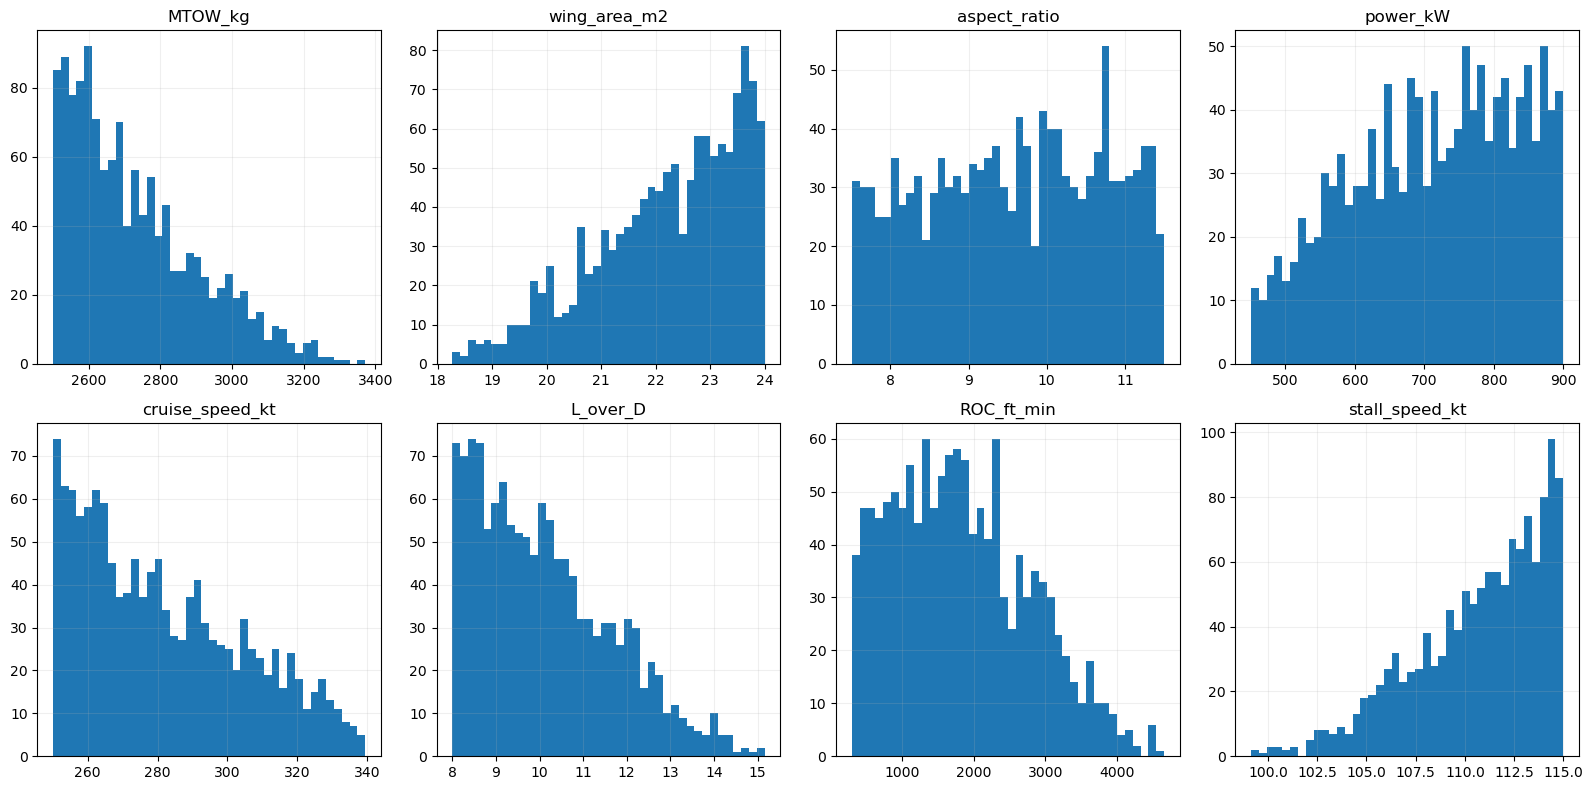

In [3]:
cols = ["MTOW_kg","wing_area_m2","aspect_ratio","power_kW","cruise_speed_kt","L_over_D","ROC_ft_min","stall_speed_kt"]
fig, axes = plt.subplots(2,4,figsize=(16,8))
for ax, col in zip(axes.ravel(), cols):
    ax.hist(df[col], bins=40); ax.set_title(col); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()


## Correlations

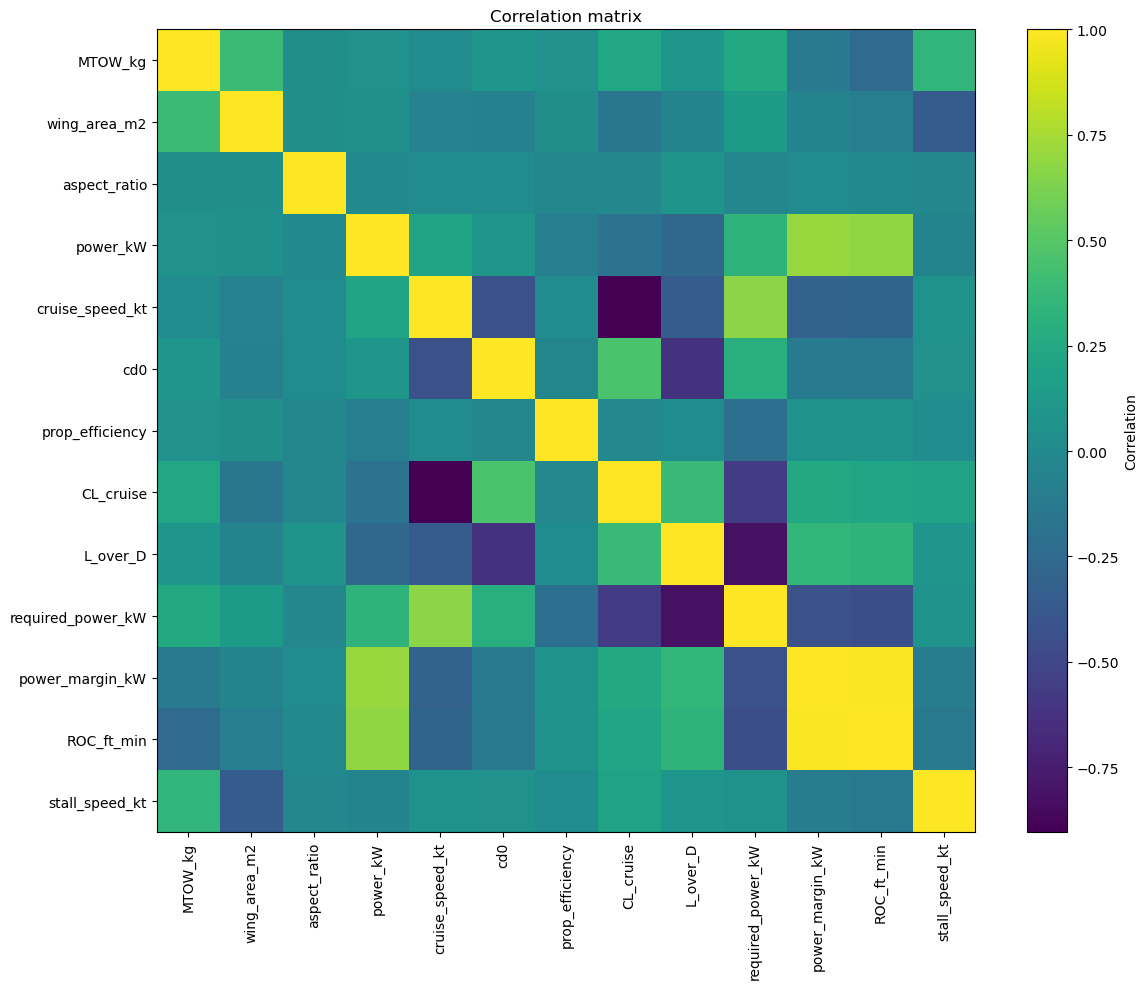

,corr_with_ROC
ROC_ft_min,1.000000
power_margin_kW,0.991752
power_kW,0.686200
L_over_D,0.333253
CL_cruise,0.216112
prop_efficiency,0.069997
aspect_ratio,0.009804
wing_area_m2,-0.092117
stall_speed_kt,-0.132595
cd0,-0.134031


In [4]:
cols = ["MTOW_kg","wing_area_m2","aspect_ratio","power_kW","cruise_speed_kt","cd0","prop_efficiency","CL_cruise","L_over_D","required_power_kW","power_margin_kW","ROC_ft_min","stall_speed_kt"]
corr = df[cols].corr()
plt.figure(figsize=(12,10)); plt.imshow(corr, aspect="auto"); plt.colorbar(label="Correlation")
plt.xticks(range(len(cols)),cols,rotation=90); plt.yticks(range(len(cols)),cols)
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()
display(corr["ROC_ft_min"].sort_values(ascending=False).to_frame("corr_with_ROC"))


## Engineering relationships

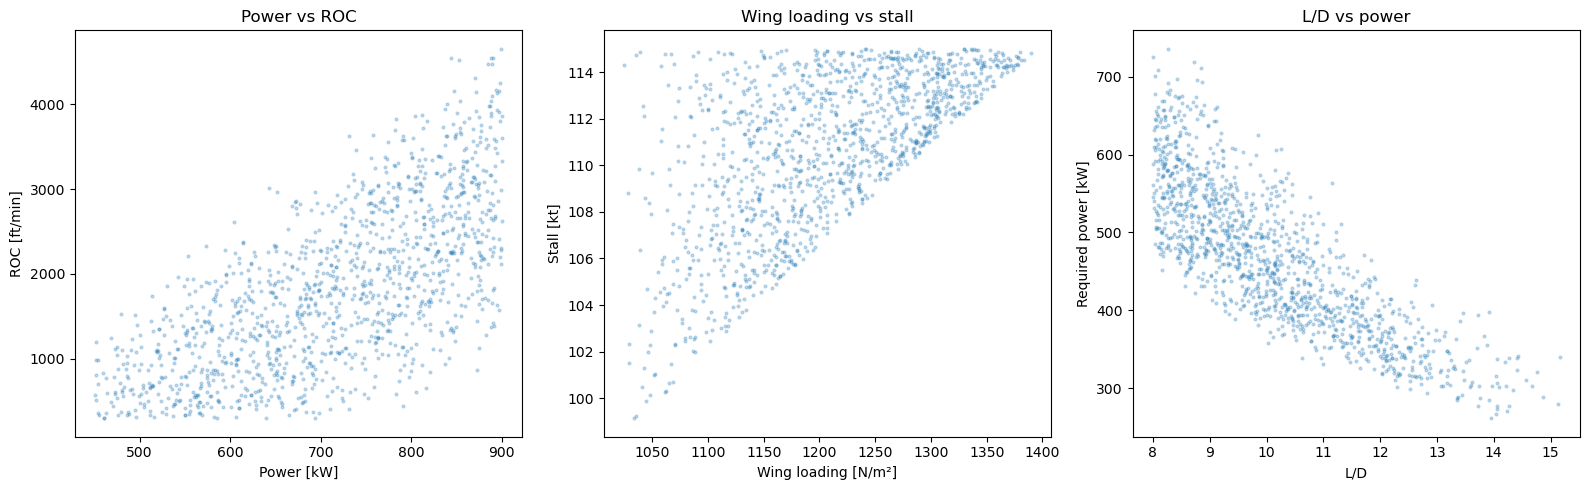

In [5]:
fig, ax = plt.subplots(1,3,figsize=(16,5))
ax[0].scatter(df.power_kW,df.ROC_ft_min,s=4,alpha=.25); ax[0].set(xlabel="Power [kW]",ylabel="ROC [ft/min]",title="Power vs ROC")
ax[1].scatter(df.weight_N/df.wing_area_m2,df.stall_speed_kt,s=4,alpha=.25); ax[1].set(xlabel="Wing loading [N/m²]",ylabel="Stall [kt]",title="Wing loading vs stall")
ax[2].scatter(df.L_over_D,df.required_power_kW,s=4,alpha=.25); ax[2].set(xlabel="L/D",ylabel="Required power [kW]",title="L/D vs power")
plt.tight_layout(); plt.show()


## TBM 960 reference point

Bu değerler örnek referans noktasıdır; kaynaklı benchmark tablosu ile değiştirilmelidir.

,MTOW_kg,wing_area_m2,power_kW,cruise_speed_kt
0,3354,18.0,1060,330


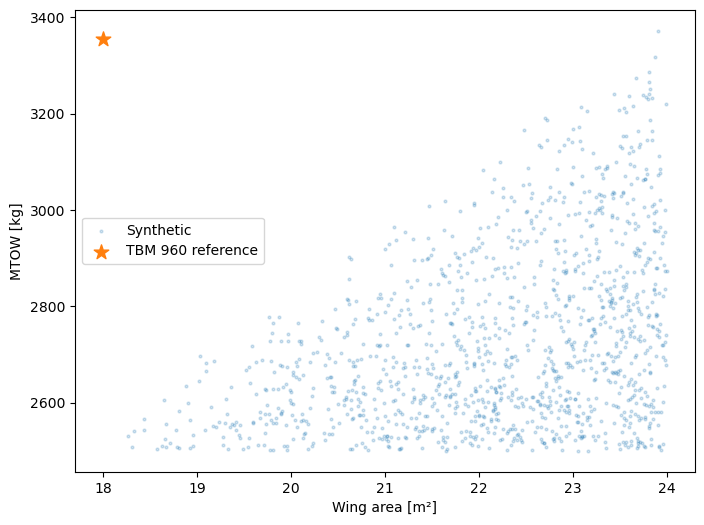

In [6]:
ref = pd.DataFrame([{"MTOW_kg":3354,"wing_area_m2":18.0,"power_kW":1060,"cruise_speed_kt":330}])
display(ref)
plt.figure(figsize=(8,6)); plt.scatter(df.wing_area_m2,df.MTOW_kg,s=4,alpha=.2,label="Synthetic")
plt.scatter(ref.wing_area_m2,ref.MTOW_kg,s=120,marker="*",label="TBM 960 reference")
plt.xlabel("Wing area [m²]"); plt.ylabel("MTOW [kg]"); plt.legend(); plt.show()


## Save EDA outputs

In [7]:
os.makedirs("outputs/eda",exist_ok=True)
summary.to_csv("outputs/eda/TBM_X_Descriptive_Statistics_v0_1.csv")
corr.to_csv("outputs/eda/TBM_X_Correlation_Matrix_v0_1.csv")
print("EDA outputs saved.")


EDA outputs saved.
